In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
data = np.load(
    '/media/joseluis/HDD/Proyecto CFD/datasets/Snapshots/snapshots_samples_64x64_full.npz',
    mmap_mode='r'
)

vort = data['vorticity']
stream = data['stream']
vort_t = data['vort_t']
residual = data['residual']

del data

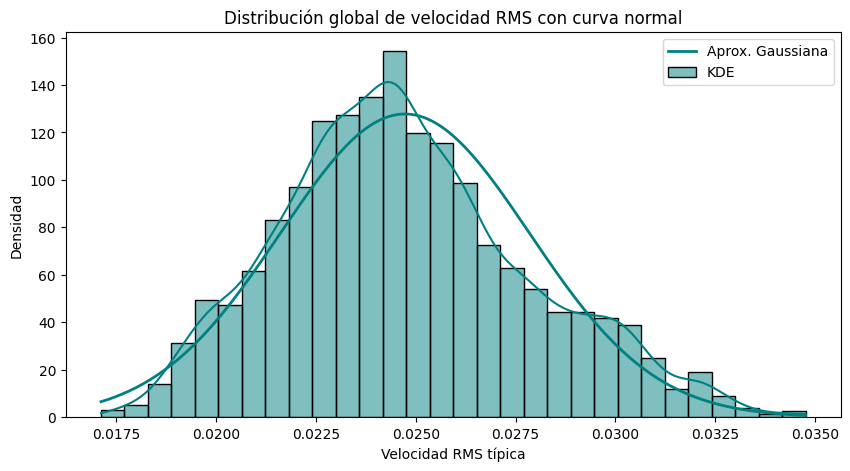

Velocidad RMS típica| media: 0.0247, desviación estándar: 0.0031


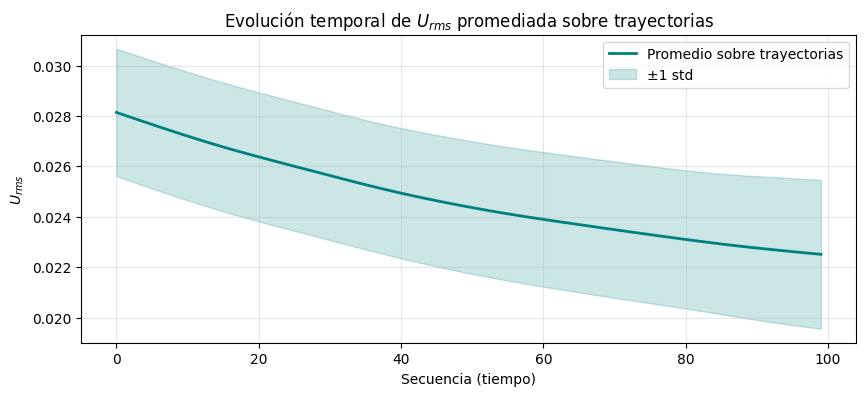

In [3]:
#Velocidad tipica del flujo: U de viscocidad UL/RE o Numero de Reynolds UL/nu
dx = dy = 1.0
n_seq, n_snap, Nx, Ny = stream.shape

psi_y, psi_x = np.gradient(stream, dy, dx, axis=(-2,-1))

u = psi_y
v = -psi_x

U_rms = np.sqrt(np.mean(u**2 + v**2, axis=(-2,-1)))

U_rms_flat = U_rms.flatten()

mean_U = np.mean(U_rms_flat)
std_U = np.std(U_rms_flat)
plt.figure(figsize=(10,5))
sns.histplot(U_rms_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(U_rms_flat.min(), U_rms_flat.max(), 200)
pdf = norm.pdf(x, loc=mean_U, scale=std_U)
plt.plot(x, pdf, 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('Velocidad RMS típica')
plt.ylabel('Densidad')
plt.title('Distribución global de velocidad RMS con curva normal')
plt.legend()
plt.show()
print(f"Velocidad RMS típica| media: {mean_U:.4f}, desviación estándar: {std_U:.4f}")

U_rms_mean_over_traj = np.mean(U_rms, axis=0)
U_rms_mean_over_time = np.mean(U_rms, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(U_rms_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap),
                 U_rms_mean_over_traj - np.std(U_rms, axis=0),
                 U_rms_mean_over_traj + np.std(U_rms, axis=0),
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$U_{rms}$')
plt.title('Evolución temporal de $U_{rms}$ promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

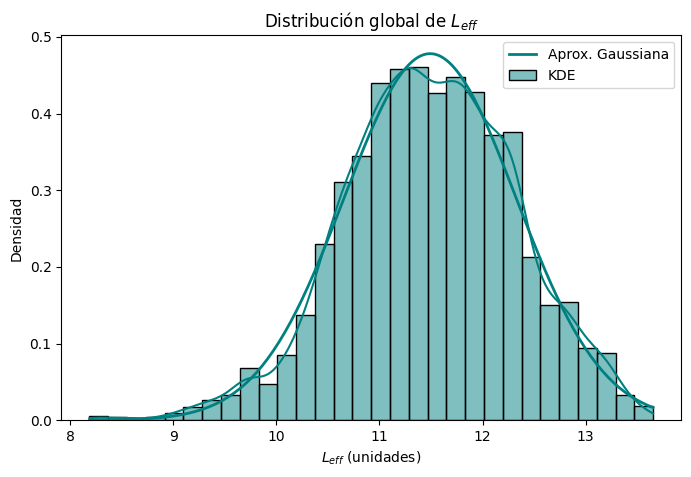

L_eff  | media: 11.4915, desviación estándar: 0.8342


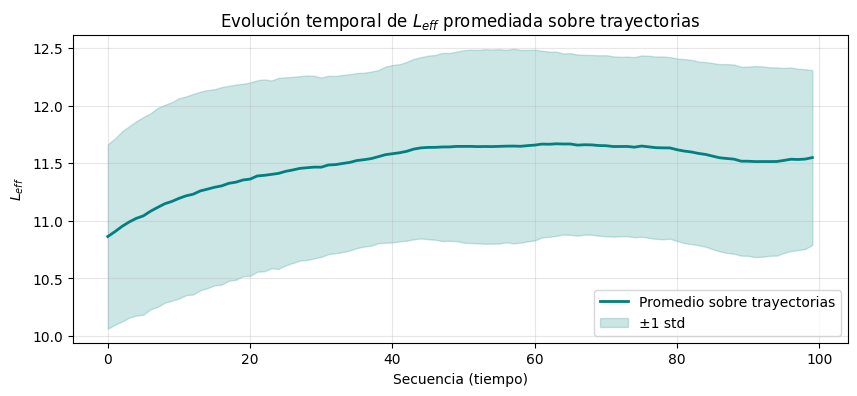

In [4]:
#Longitud especial efectiva: L de viscocidad UL/RE o Numero de Reynolds UL/nu
n_seq, n_snap, Nx, Ny = vort.shape

kx = np.fft.fftfreq(Nx) * 2 * np.pi
ky = np.fft.fftfreq(Ny) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K      = np.sqrt(KX**2 + KY**2)
k_vals = np.unique(np.round(K, 6))
mask_k = k_vals > 0

K_mean = np.zeros((n_seq, n_snap))
L_eff  = np.zeros((n_seq, n_snap))

for t in range(n_seq):
    for s in range(n_snap):
        omega = vort[t, s]

        omega_hat = np.fft.fft2(omega) / (Nx * Ny)
        poder     = np.abs(omega_hat)**2
        E_k       = np.array([
            np.sum(poder[np.isclose(K, k, atol=1e-6)])
            for k in k_vals
        ])

        K_mean[t, s] = (np.sum(k_vals[mask_k] * E_k[mask_k]) /
                        np.sum(E_k[mask_k]))

        L_eff[t, s] = 2 * np.pi / K_mean[t, s]

L_eff_flat = L_eff.flatten()
mean_L     = np.mean(L_eff_flat)
std_L      = np.std(L_eff_flat)

plt.figure(figsize=(8, 5))
sns.histplot(L_eff_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(L_eff_flat.min(), L_eff_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_L, std_L), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$L_{eff}$ (unidades)')
plt.ylabel('Densidad')
plt.title('Distribución global de $L_{eff}$')
plt.legend()
plt.show()
print(f"L_eff  | media: {mean_L:.4f}, desviación estándar: {std_L:.4f}")

Leff_mean_over_traj = np.mean(L_eff, axis=0)
Leff_std_over_traj  = np.std(L_eff,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Leff_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap),
                 Leff_mean_over_traj - Leff_std_over_traj,
                 Leff_mean_over_traj + Leff_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$L_{eff}$')
plt.title('Evolución temporal de $L_{eff}$ promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

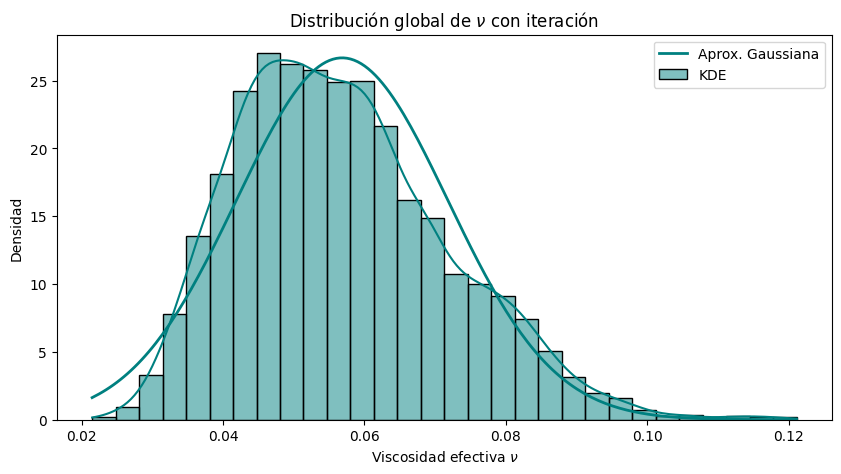


ν  | media: 0.056853, std: 0.014952


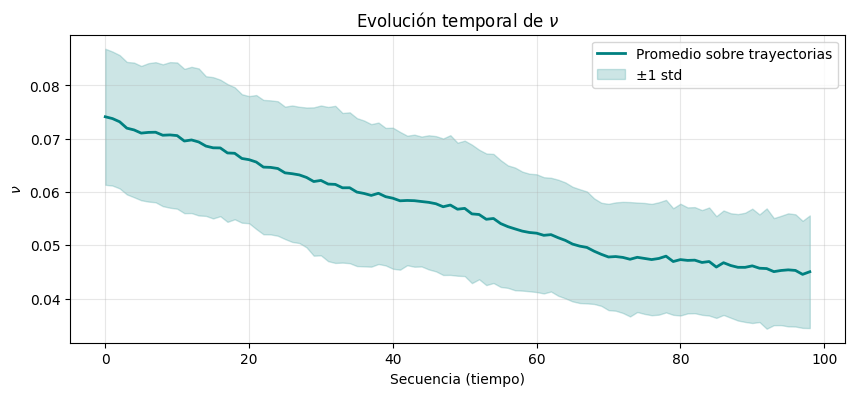

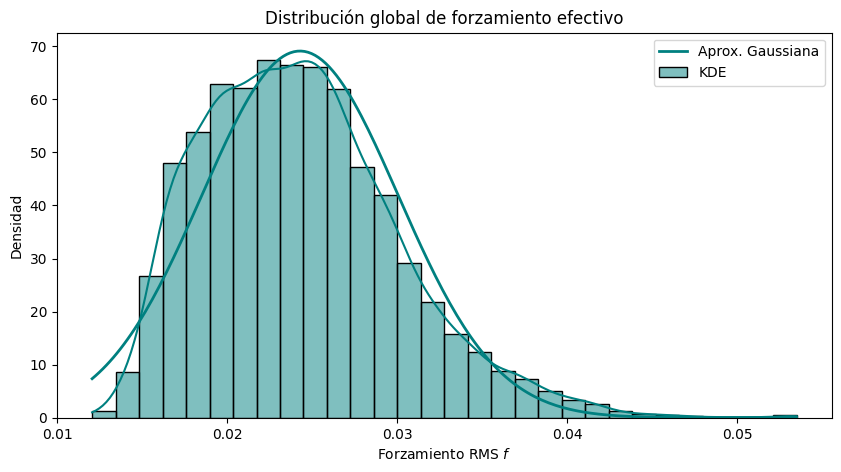

f | media: 0.024284, desviación estándar: 0.005773


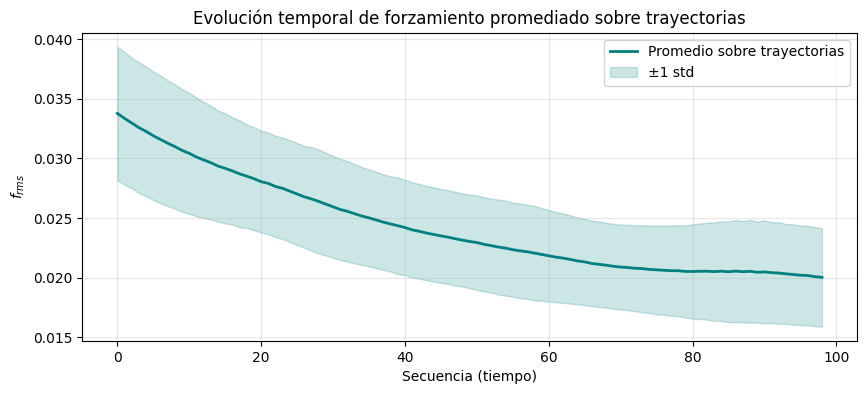

In [5]:
dx = dy = dt = 1.0
n_seq, n_snap, Nx, Ny = vort.shape

kx = np.fft.fftfreq(Nx) * 2 * np.pi
ky = np.fft.fftfreq(Ny) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2

Nu_eff = np.zeros((n_seq, n_snap - 1))
F_eff  = np.zeros((n_seq, n_snap - 1, Nx, Ny))

max_iter  = 50
tol       = 1e-8

for t in range(n_seq):
    for s in range(n_snap - 1):

        omega   = vort[t, s]
        omega_1 = vort[t, s + 1]
        psi     = stream[t, s]

        dt_omega = (omega_1 - omega) / dt

        psi_y, psi_x = np.gradient(psi, dy, dx)
        u =  psi_y
        v = -psi_x

        dw_y, dw_x = np.gradient(omega, dy, dx)
        adveccion = u * dw_x + v * dw_y

        omega_hat = np.fft.fft2(omega)
        lap_omega = np.real(np.fft.ifft2(-K2 * omega_hat))

        rhs = dt_omega + adveccion

        f_n   = np.zeros((Nx, Ny))
        nu_n  = 0.0

        for it in range(max_iter):
            # ν^(n+1) = <(rhs - f) · ∇²ω> / <(∇²ω)²>
            numerador   = np.mean((rhs - f_n) * lap_omega)
            denominador = np.mean(lap_omega**2)
            nu_new = numerador / denominador if denominador != 0 else 0.0
            # f^(n+1) = rhs - ν^(n+1) · ∇²ω
            f_new = rhs - nu_new * lap_omega

            error_nu = abs(nu_new - nu_n)
            error_f  = np.mean(np.abs(f_new - f_n))

            nu_n = nu_new
            f_n  = f_new

            if error_nu < tol and error_f < tol:
                break
                
        Nu_eff[t, s]    = nu_n
        F_eff[t, s]     = f_n


# ══════════════════════════════════════════════════════════════
# VISUALIZACIÓN — ν
# ══════════════════════════════════════════════════════════════
Nu_flat = Nu_eff.flatten()
mean_nu = np.mean(Nu_flat)
std_nu  = np.std(Nu_flat)

plt.figure(figsize=(10, 5))
sns.histplot(Nu_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Nu_flat.min(), Nu_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_nu, std_nu), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('Viscosidad efectiva $\\nu$')
plt.ylabel('Densidad')
plt.title('Distribución global de $\\nu$ con iteración')
plt.legend()
plt.show()
print(f"\nν  | media: {np.mean(Nu_eff):.6f}, std: {np.std(Nu_eff):.6f}")


Nu_mean_over_traj = np.mean(Nu_eff, axis=0)
Nu_std_over_traj  = np.std(Nu_eff,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Nu_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap - 1),
                 Nu_mean_over_traj - Nu_std_over_traj,
                 Nu_mean_over_traj + Nu_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\nu$')
plt.title('Evolución temporal de $\\nu$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ══════════════════════════════════════════════════════════════
# VISUALIZACIÓN — f (forzamiento) mismo patrón que las demás
# ══════════════════════════════════════════════════════════════

# F_eff tiene shape (n_seq, n_snap-1, Nx, Ny)
# Necesitamos un escalar por frame → usamos la norma RMS espacial
F_rms = np.sqrt(np.mean(F_eff**2, axis=(-2, -1)))  # (n_seq, n_snap-1)

# ── Estadística global ─────────────────────────────────────────
F_flat  = F_rms.flatten()
mean_f  = np.mean(F_flat)
std_f   = np.std(F_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.histplot(F_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(F_flat.min(), F_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_f, std_f), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('Forzamiento RMS $f$')
plt.ylabel('Densidad')
plt.title('Distribución global de forzamiento efectivo')
plt.legend()
plt.show()
print(f"f | media: {mean_f:.6f}, desviación estándar: {std_f:.6f}")

# ── Evolución temporal ─────────────────────────────────────────
F_mean_over_traj = np.mean(F_rms, axis=0)   # (n_snap-1,)
F_std_over_traj  = np.std(F_rms,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(F_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap - 1),
                 F_mean_over_traj - F_std_over_traj,
                 F_mean_over_traj + F_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$f_{rms}$')
plt.title('Evolución temporal de forzamiento promediado sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando Número de Reynolds Re...


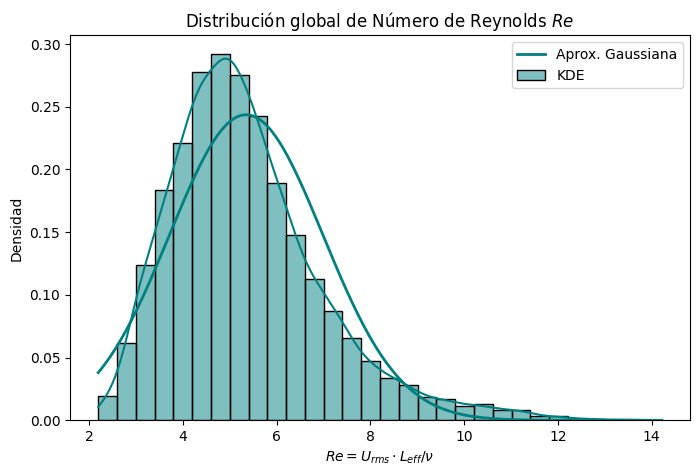

Re | media: 5.3508, desviación estándar: 1.6373


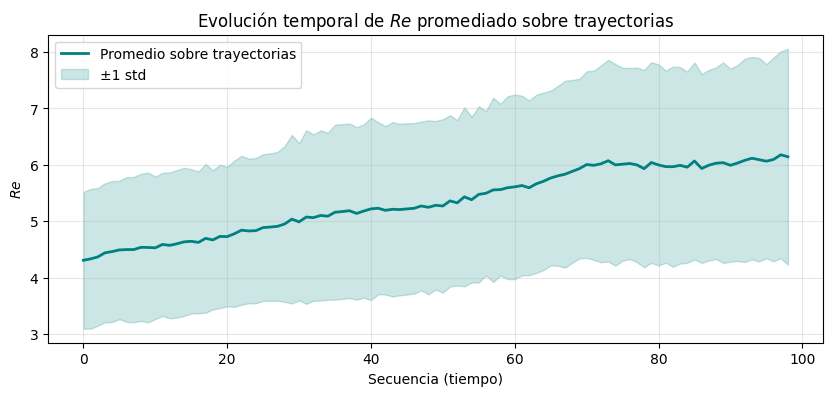

In [6]:
# ══════════════════════════════════════════════════════════════════════
# NÚMERO DE REYNOLDS: Re = U_rms · L_eff / ν
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando Número de Reynolds Re...")

# U_rms es (n_seq, n_snap), L_eff es (n_seq, n_snap), Nu_eff es (n_seq, n_snap-1)
# Recortamos U_rms y L_eff para que coincidan con Nu_eff
Re = (U_rms[:, :-1] * L_eff[:, :-1]) / Nu_eff   # (n_seq, n_snap-1)

# ── Estadística global ─────────────────────────────────────────
Re_flat  = Re.flatten()
mean_re  = np.mean(Re_flat)
std_re   = np.std(Re_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(Re_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Re_flat.min(), Re_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_re, std_re), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$Re = U_{rms} \\cdot L_{eff} / \\nu$')
plt.ylabel('Densidad')
plt.title('Distribución global de Número de Reynolds $Re$')
plt.legend()
plt.show()
print(f"Re | media: {mean_re:.4f}, desviación estándar: {std_re:.4f}")

# ── Evolución temporal ─────────────────────────────────────────
Re_mean_over_traj = np.mean(Re, axis=0)   # (n_snap-1,)
Re_std_over_traj  = np.std(Re,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Re_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap - 1),
                 Re_mean_over_traj - Re_std_over_traj,
                 Re_mean_over_traj + Re_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$Re$')
plt.title('Evolución temporal de $Re$ promediado sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

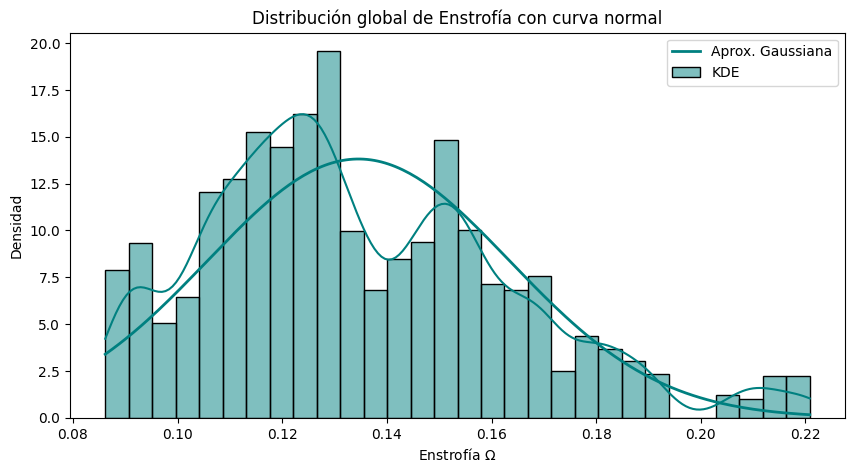

Z | media: 0.1346, desviación estándar: 0.0289


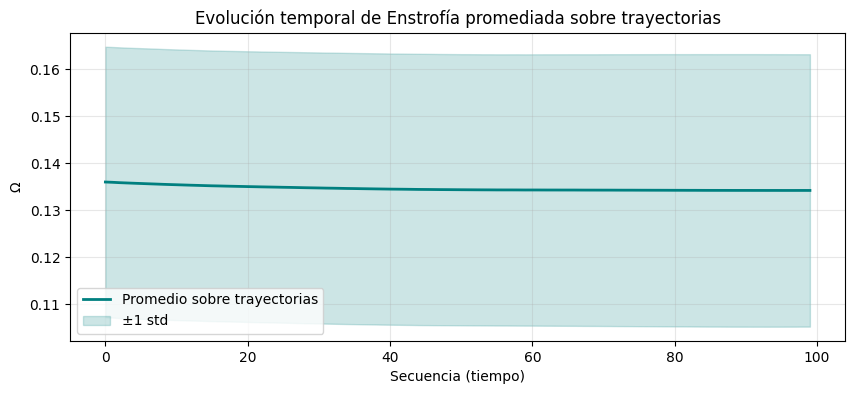

In [7]:
#Enstrofia: Funcional de campo Z
n_seq, n_snap, Nx, Ny = vort.shape
Enstrophy = 0.5 * np.sum(vort**2, axis=(-2,-1)) / (Nx * Ny)  # (100, 100)

Enstrophy_flat = Enstrophy.flatten()
mean_Z = np.mean(Enstrophy_flat)
std_Z  = np.std(Enstrophy_flat)

plt.figure(figsize=(10, 5))
sns.histplot(Enstrophy_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Enstrophy_flat.min(), Enstrophy_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_Z, std_Z), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('Enstrofía $\\Omega$')
plt.ylabel('Densidad')
plt.title('Distribución global de Enstrofía con curva normal')
plt.legend()
plt.show()
print(f"Z | media: {mean_Z:.4f}, desviación estándar: {std_Z:.4f}")

Enstrophy_mean_over_traj = np.mean(Enstrophy, axis=0)
Enstrophy_std_over_traj  = np.std(Enstrophy,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Enstrophy_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap),
                 Enstrophy_mean_over_traj - Enstrophy_std_over_traj,
                 Enstrophy_mean_over_traj + Enstrophy_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\Omega$')
plt.title('Evolución temporal de Enstrofía promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando gradiente de vorticidad η...


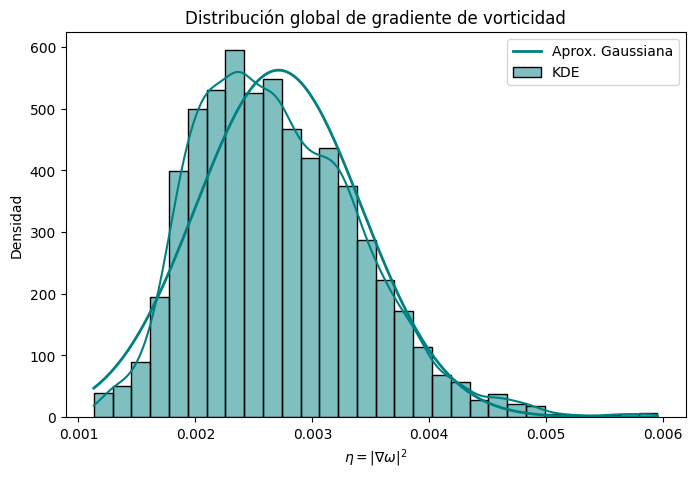

η | media: 0.002711, desviación estándar: 0.000709


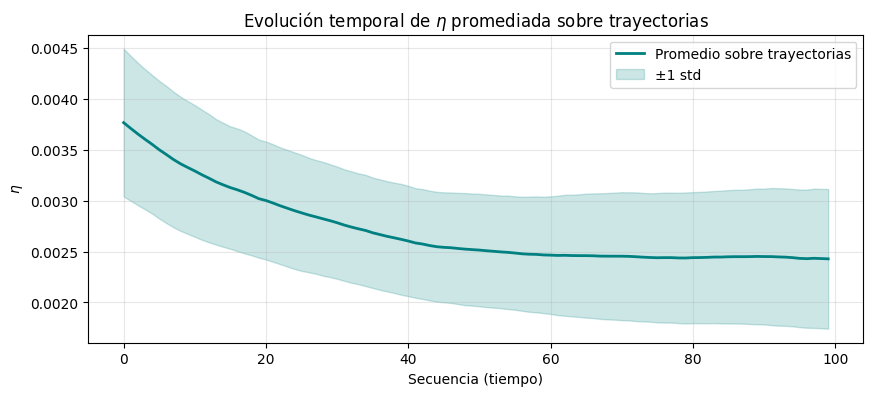

In [8]:
# ══════════════════════════════════════════════════════════════════════
# GRADIENTE DE VORTICIDAD: η = 1/NxNy Σᵢⱼ |∇ωᵢⱼ|²
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando gradiente de vorticidad η...")

dx = dy = 1.0
n_seq, n_snap, Nx, Ny = vort.shape

# Gradientes espaciales vectorizados
dw_y, dw_x = np.gradient(vort, dy, dx, axis=(-2, -1))

# 1/NxNy Σᵢⱼ (∂ₓω)² + (∂ᵧω)²
Grad_vort = np.mean(dw_x**2 + dw_y**2, axis=(-2, -1))  # (n_seq, n_snap)

# ── Estadística global ─────────────────────────────────────────
GV_flat  = Grad_vort.flatten()
mean_gv  = np.mean(GV_flat)
std_gv   = np.std(GV_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(GV_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(GV_flat.min(), GV_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_gv, std_gv), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$\\eta = |\\nabla\\omega|^2$')
plt.ylabel('Densidad')
plt.title('Distribución global de gradiente de vorticidad')
plt.legend()
plt.show()
print(f"η | media: {mean_gv:.6f}, desviación estándar: {std_gv:.6f}")

# ── Evolución temporal ─────────────────────────────────────────
GV_mean_over_traj = np.mean(Grad_vort, axis=0)  # (n_snap,)
GV_std_over_traj  = np.std(Grad_vort,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(GV_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap),
                 GV_mean_over_traj - GV_std_over_traj,
                 GV_mean_over_traj + GV_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\eta$')
plt.title('Evolución temporal de $\\eta$ promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando disipación de enstrofía D...


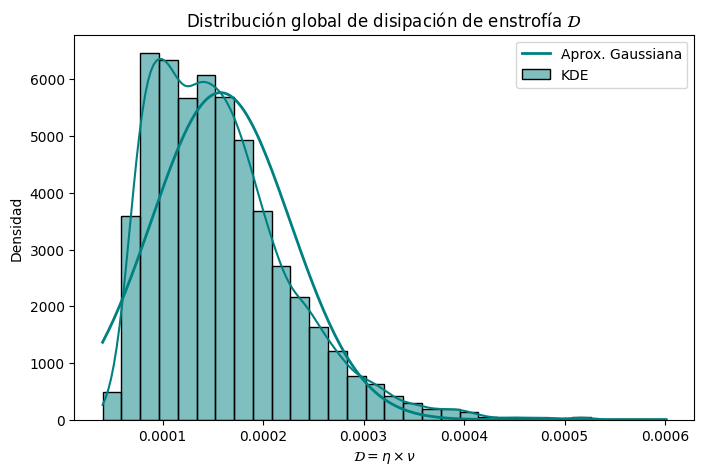

D | media: 0.000158, desviación estándar: 0.000069


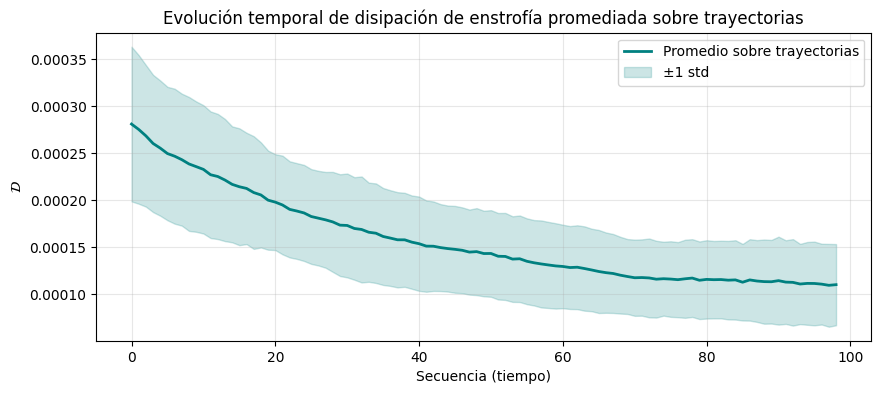

In [9]:
# ══════════════════════════════════════════════════════════════════════
# DISIPACIÓN DE ENSTROFÍA: D = η × ν
#                            = |∇ω|² × ν
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando disipación de enstrofía D...")

# Grad_vort es (n_seq, n_snap), Nu_eff es (n_seq, n_snap-1)
# Recortamos Grad_vort para que coincidan
Dissipation = Grad_vort[:, :-1] * Nu_eff   # (n_seq, n_snap-1)

# ── Estadística global ─────────────────────────────────────────
Diss_flat = Dissipation.flatten()
mean_d    = np.mean(Diss_flat)
std_d     = np.std(Diss_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(Diss_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Diss_flat.min(), Diss_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_d, std_d), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$\\mathcal{D} = \\eta \\times \\nu$')
plt.ylabel('Densidad')
plt.title('Distribución global de disipación de enstrofía $\\mathcal{D}$')
plt.legend()
plt.show()
print(f"D | media: {mean_d:.6f}, desviación estándar: {std_d:.6f}")

# ── Evolución temporal ─────────────────────────────────────────
Diss_mean_over_traj = np.mean(Dissipation, axis=0)   # (n_snap-1,)
Diss_std_over_traj  = np.std(Dissipation,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Diss_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap - 1),
                 Diss_mean_over_traj - Diss_std_over_traj,
                 Diss_mean_over_traj + Diss_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\mathcal{D}$')
plt.title('Evolución temporal de disipación de enstrofía promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando resistencia viscosa ε...


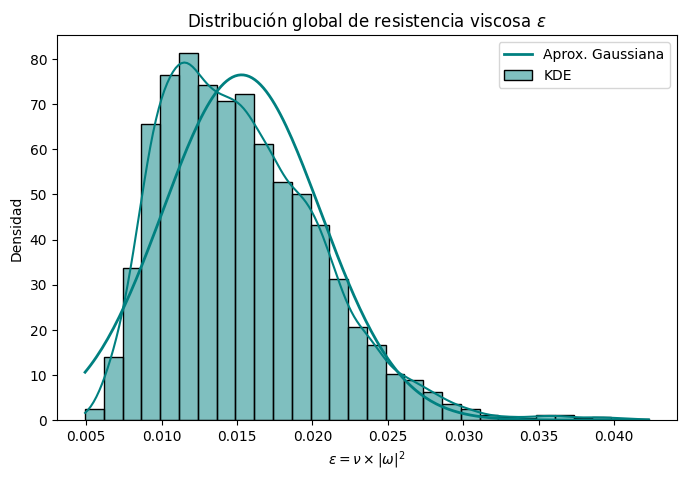

ε | media: 0.015301, desviación estándar: 0.005218


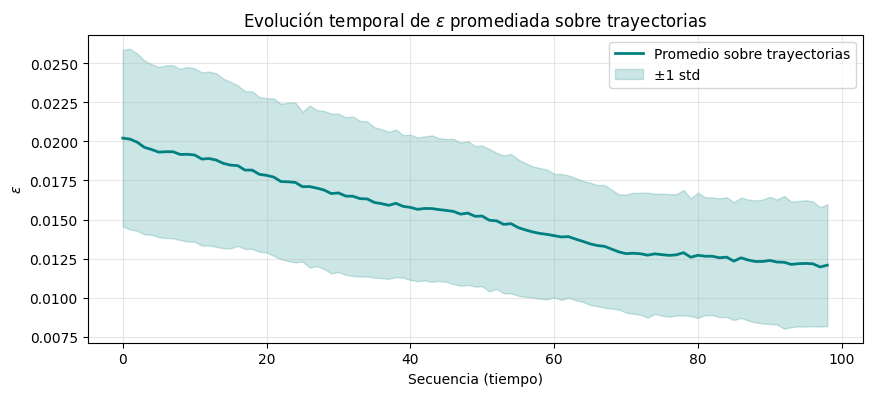

In [10]:
# ══════════════════════════════════════════════════════════════════════
# RESISTENCIA VISCOSA: ε = ν × 1/NxNy Σᵢⱼ ωᵢⱼ²
#                       = ν × 2Ω
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando resistencia viscosa ε...")

# Nu_eff es (n_seq, n_snap-1), Enstrophy es (n_seq, n_snap)
# Recortamos Enstrophy para que coincidan
Epsilon = Nu_eff * (2 * Enstrophy[:, :-1])   # (n_seq, n_snap-1)

# ── Estadística global ─────────────────────────────────────────
Eps_flat = Epsilon.flatten()
mean_eps = np.mean(Eps_flat)
std_eps  = np.std(Eps_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(Eps_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Eps_flat.min(), Eps_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_eps, std_eps), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$\\epsilon = \\nu \\times |\\omega|^2$')
plt.ylabel('Densidad')
plt.title('Distribución global de resistencia viscosa $\\epsilon$')
plt.legend()
plt.show()
print(f"ε | media: {mean_eps:.6f}, desviación estándar: {std_eps:.6f}")

# ── Evolución temporal ─────────────────────────────────────────
Eps_mean_over_traj = np.mean(Epsilon, axis=0)   # (n_snap-1,)
Eps_std_over_traj  = np.std(Epsilon,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Eps_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap - 1),
                 Eps_mean_over_traj - Eps_std_over_traj,
                 Eps_mean_over_traj + Eps_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\epsilon$')
plt.title('Evolución temporal de $\\epsilon$ promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


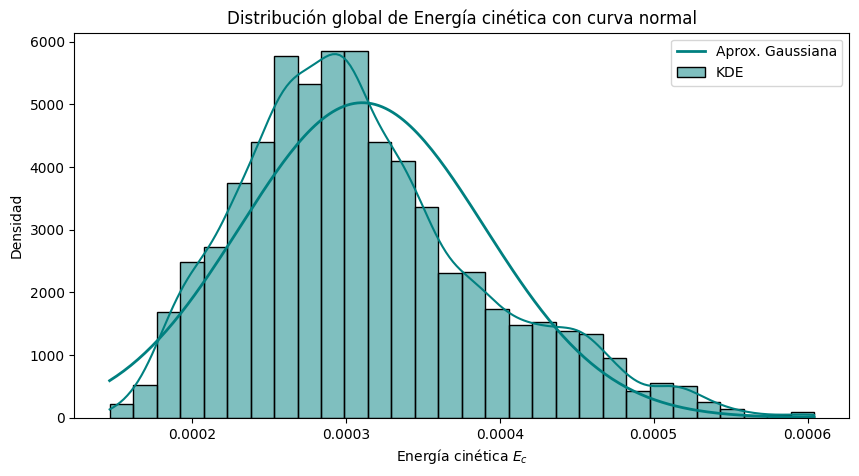

Energía cinética | media: 0.0003, desviación estándar: 0.0001


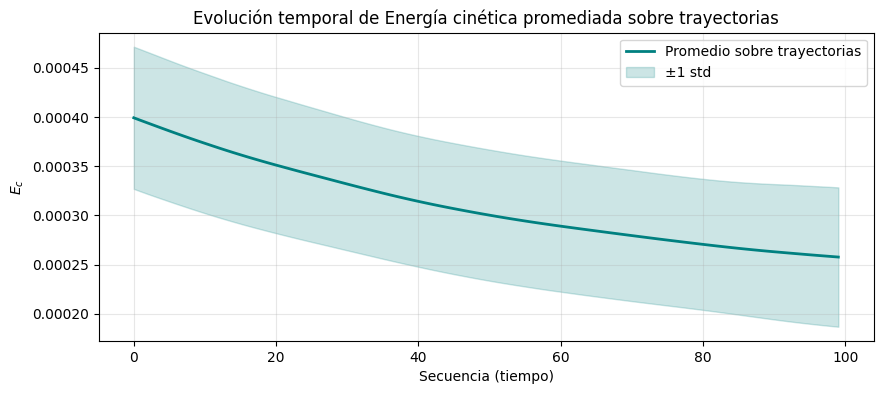

In [11]:
#Energia cinetica: Funcional de campo E_c
dx = dy = 1.0
n_seq, n_snap, Nx, Ny = stream.shape

psi_y, psi_x = np.gradient(stream, dy, dx, axis=(-2,-1))
u =  psi_y
v = -psi_x

KineticEnergy = 0.5 * np.mean(u**2 + v**2, axis=(-2,-1))

KE_flat = KineticEnergy.flatten()
mean_E  = np.mean(KE_flat)
std_E   = np.std(KE_flat)

plt.figure(figsize=(10, 5))
sns.histplot(KE_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(KE_flat.min(), KE_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_E, std_E), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('Energía cinética $E_c$')
plt.ylabel('Densidad')
plt.title('Distribución global de Energía cinética con curva normal')
plt.legend()
plt.show()
print(f"Energía cinética | media: {mean_E:.4f}, desviación estándar: {std_E:.4f}")

KE_mean_over_traj = np.mean(KineticEnergy, axis=0)
KE_std_over_traj  = np.std(KineticEnergy,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(KE_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap),
                 KE_mean_over_traj - KE_std_over_traj,
                 KE_mean_over_traj + KE_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$E_c$')
plt.title('Evolución temporal de Energía cinética promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando tiempo característico de remolino τ...


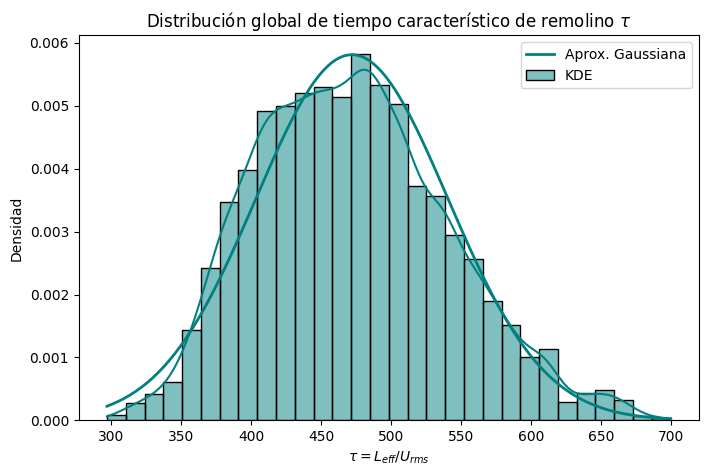

τ | media: 472.047686, desviación estándar: 68.631176


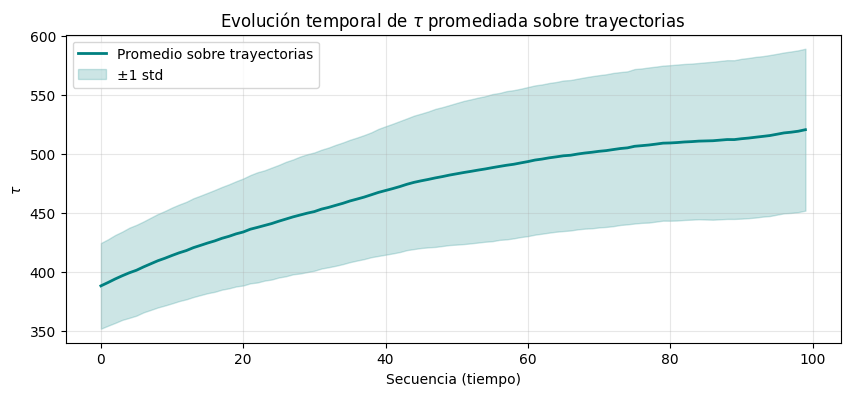

In [12]:
# ══════════════════════════════════════════════════════════════════════
# TIEMPO CARACTERÍSTICO DE REMOLINO: τ = L_eff / U_rms
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando tiempo característico de remolino τ...")

# L_eff es (n_seq, n_snap), U_rms es (n_seq, n_snap)
Tau = L_eff / U_rms   # (n_seq, n_snap)

# ── Estadística global ─────────────────────────────────────────
Tau_flat = Tau.flatten()
mean_tau = np.mean(Tau_flat)
std_tau  = np.std(Tau_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(Tau_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Tau_flat.min(), Tau_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_tau, std_tau), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$\\tau = L_{eff} / U_{rms}$')
plt.ylabel('Densidad')
plt.title('Distribución global de tiempo característico de remolino $\\tau$')
plt.legend()
plt.show()
print(f"τ | media: {mean_tau:.6f}, desviación estándar: {std_tau:.6f}")

# ── Evolución temporal ─────────────────────────────────────────
Tau_mean_over_traj = np.mean(Tau, axis=0)   # (n_snap,)
Tau_std_over_traj  = np.std(Tau,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Tau_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap),
                 Tau_mean_over_traj - Tau_std_over_traj,
                 Tau_mean_over_traj + Tau_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\tau$')
plt.title('Evolución temporal de $\\tau$ promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando autocorrelación temporal C(τ) via FFT...


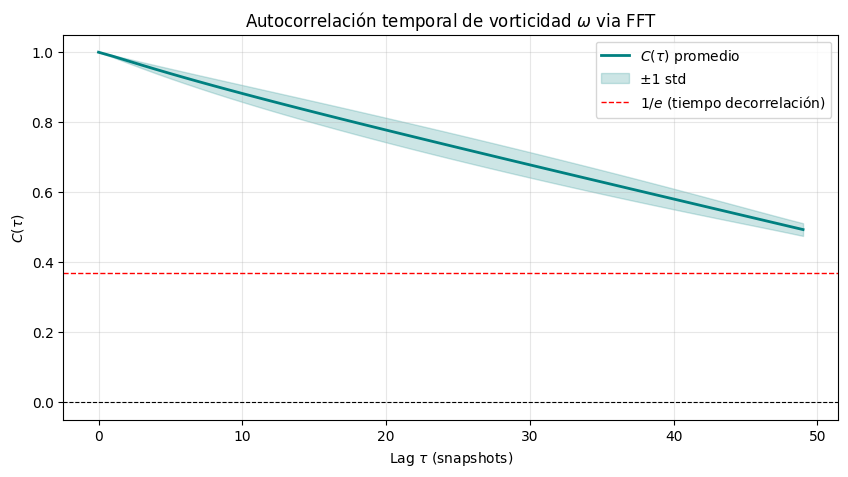

C(0)  = 1.0000  (debe ser ≈ 1)
τ*    = 49 snapshots  (tiempo de decorrelación)
C(τ*) = 0.4933


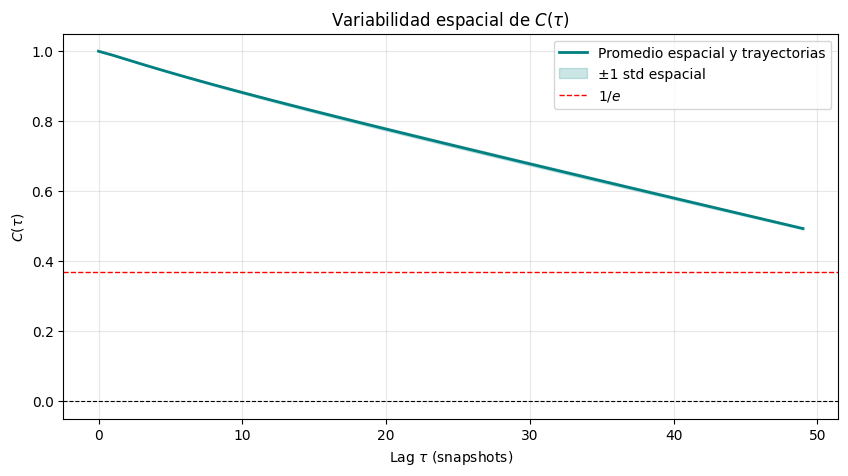

In [19]:
# ══════════════════════════════════════════════════════════════════════
# AUTOCORRELACIÓN TEMPORAL via FFT (Wiener-Khinchin)
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando autocorrelación temporal C(τ) via FFT...")

n_seq, n_snap, Nx, Ny = vort.shape
max_tau = n_snap // 2   # lags útiles (mitad para evitar efectos de borde)

C_tau_all = np.zeros((n_seq, Nx, Ny, max_tau))

for t in range(n_seq):
    for i in range(Nx):
        for j in range(Ny):
            # Serie temporal en el punto (i,j)
            serie = vort[t, :, i, j]          # (n_snap,)

            # Autocorrelación via FFT
            serie_hat  = np.fft.fft(serie, n=2*n_snap)   # zero-padding
            power      = np.abs(serie_hat)**2
            corr       = np.real(np.fft.ifft(power))      # (2*n_snap,)
            corr       = corr[:n_snap]                     # tomar lags positivos

            # Normalizar C(0) = 1
            if corr[0] != 0:
                corr /= corr[0]

            C_tau_all[t, i, j, :] = corr[:max_tau]

# ── Promedio espacial y sobre trayectorias ─────────────────────
C_tau_mean = np.mean(C_tau_all, axis=(0, 1, 2))   # (max_tau,)
C_tau_std  = np.std(C_tau_all,  axis=(0, 1, 2))

# ── Gráfica de autocorrelación temporal ───────────────────────
tau_vals = np.arange(max_tau)

plt.figure(figsize=(10, 5))
plt.plot(tau_vals, C_tau_mean, color='teal', lw=2, label='$C(\\tau)$ promedio')
plt.fill_between(tau_vals,
                 C_tau_mean - C_tau_std,
                 C_tau_mean + C_tau_std,
                 alpha=0.2, color='teal', label='±1 std')
plt.axhline(0,      color='black', lw=0.8, linestyle='--')
plt.axhline(1/np.e, color='red',   lw=1,   linestyle='--', label='$1/e$ (tiempo decorrelación)')
plt.xlabel('Lag $\\tau$ (snapshots)')
plt.ylabel('$C(\\tau)$')
plt.title('Autocorrelación temporal de vorticidad $\\omega$ via FFT')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ── Tiempo de decorrelación τ* donde C(τ*) = 1/e ──────────────
tau_decorr = np.argmin(np.abs(C_tau_mean - 1/np.e))
print(f"C(0)  = {C_tau_mean[0]:.4f}  (debe ser ≈ 1)")
print(f"τ*    = {tau_decorr} snapshots  (tiempo de decorrelación)")
print(f"C(τ*) = {C_tau_mean[tau_decorr]:.4f}")

# ── Evolución espacial de C(τ) ─────────────────────────────────
# Promedio solo sobre trayectorias → ver variación espacial
C_tau_spatial = np.mean(C_tau_all, axis=0)         # (Nx, Ny, max_tau)
C_tau_spatial_mean = np.mean(C_tau_spatial, axis=(0,1))  # ya es C_tau_mean
C_tau_spatial_std  = np.std(C_tau_spatial,  axis=(0,1))  # variabilidad espacial

plt.figure(figsize=(10, 5))
plt.plot(tau_vals, C_tau_mean, color='teal', lw=2, label='Promedio espacial y trayectorias')
plt.fill_between(tau_vals,
                 C_tau_mean - C_tau_spatial_std,
                 C_tau_mean + C_tau_spatial_std,
                 alpha=0.2, color='teal', label='±1 std espacial')
plt.axhline(0,      color='black', lw=0.8, linestyle='--')
plt.axhline(1/np.e, color='red',   lw=1,   linestyle='--', label='$1/e$')
plt.xlabel('Lag $\\tau$ (snapshots)')
plt.ylabel('$C(\\tau)$')
plt.title('Variabilidad espacial de $C(\\tau)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


── Calculando tasa de cambio normalizada ε...


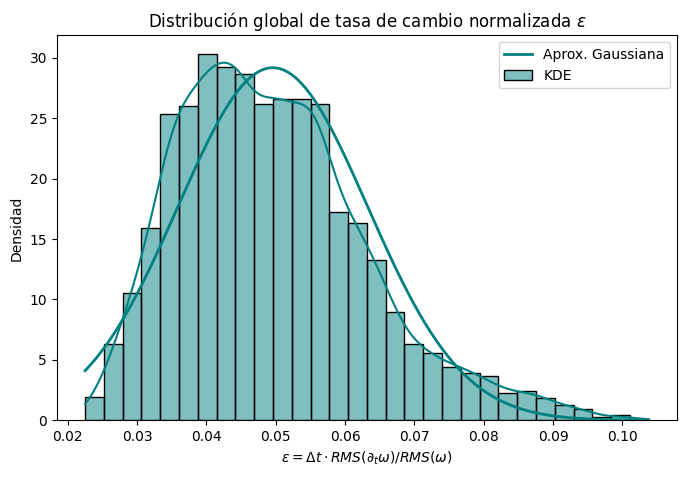

ε | media: 0.049585, desviación estándar: 0.013671


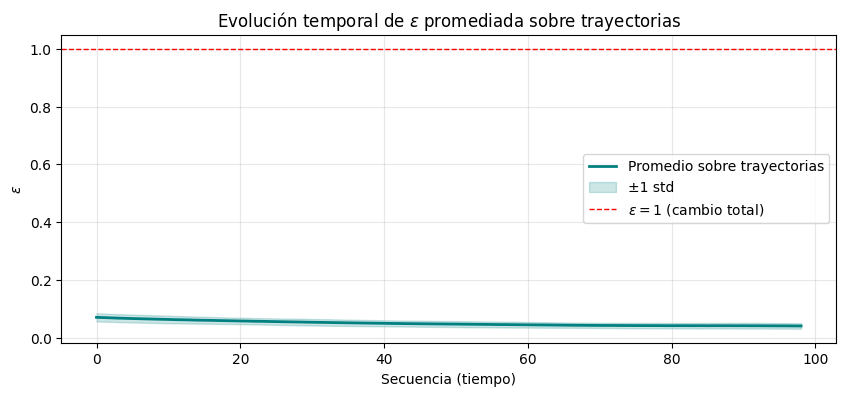

In [16]:
# ══════════════════════════════════════════════════════════════════════
# TASA DE CAMBIO NORMALIZADA: ε = Δt · RMS(∂ₜω) / RMS(ω)
# ══════════════════════════════════════════════════════════════════════
print("\n── Calculando tasa de cambio normalizada ε...")

dt = 1.0
n_seq, n_snap, Nx, Ny = vort.shape

# ∂ₜω por diferencia finita → shape (n_seq, n_snap-1, Nx, Ny)
dt_omega = np.diff(vort, axis=1) / dt

# ── Numerador: sqrt(1/NxNy Σᵢⱼ (∂ₜωᵢⱼ)²) ─────────────────────
RMS_dt_omega = np.sqrt(np.mean(dt_omega**2, axis=(-2, -1)))  # (n_seq, n_snap-1)

# ── Denominador: sqrt(1/NxNy Σᵢⱼ ωᵢⱼ²) ───────────────────────
RMS_omega = np.sqrt(np.mean(vort[:, :-1]**2, axis=(-2, -1))) # (n_seq, n_snap-1)

# ── ε = Δt · RMS(∂ₜω) / RMS(ω) ───────────────────────────────
Epsilon_norm = dt * RMS_dt_omega / RMS_omega                  # (n_seq, n_snap-1)

# ── Estadística global ─────────────────────────────────────────
Eps_flat = Epsilon_norm.flatten()
mean_eps = np.mean(Eps_flat)
std_eps  = np.std(Eps_flat)

# ── Distribución global ────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.histplot(Eps_flat, bins=30, color='teal', kde=True, stat="density", label='KDE')
x = np.linspace(Eps_flat.min(), Eps_flat.max(), 200)
plt.plot(x, norm.pdf(x, mean_eps, std_eps), 'teal', lw=2, label='Aprox. Gaussiana')
plt.xlabel('$\\epsilon = \\Delta t \\cdot RMS(\\partial_t\\omega) / RMS(\\omega)$')
plt.ylabel('Densidad')
plt.title('Distribución global de tasa de cambio normalizada $\\epsilon$')
plt.legend()
plt.show()
print(f"ε | media: {mean_eps:.6f}, desviación estándar: {std_eps:.6f}")

# ── Evolución temporal ─────────────────────────────────────────
Eps_mean_over_traj = np.mean(Epsilon_norm, axis=0)   # (n_snap-1,)
Eps_std_over_traj  = np.std(Epsilon_norm,  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(Eps_mean_over_traj, color='teal', lw=2, label='Promedio sobre trayectorias')
plt.fill_between(range(n_snap - 1),
                 Eps_mean_over_traj - Eps_std_over_traj,
                 Eps_mean_over_traj + Eps_std_over_traj,
                 alpha=0.2, color='teal', label='±1 std')
plt.axhline(1.0, color='red', lw=1, linestyle='--', label='$\\epsilon = 1$ (cambio total)')
plt.xlabel('Secuencia (tiempo)')
plt.ylabel('$\\epsilon$')
plt.title('Evolución temporal de $\\epsilon$ promediada sobre trayectorias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
cantidades = {
    'Enstrofía Ω':          Enstrophy,
    'U_rms':                U_rms,
    'Energía cinética Ec':  KineticEnergy,
    'k_mean':               K_mean,
    'L_eff':                L_eff,
    'Grad. vorticidad η':   Grad_vort,
    'Tiempo remolino τ':    Tau,
    'Viscosidad ν':         Nu_eff,
    'Forzamiento f_rms':    F_rms,
    'Resistencia ε':        Epsilon,
    'Disipación D':         Dissipation,
    'Reynolds Re':          Re,
    'Tasa cambio ε_norm':   Epsilon_norm,
}

print("═" * 55)
print(f"{'Cantidad':<25} {'Media':>12} {'Std':>12}")
print("═" * 55)
for nombre, datos in cantidades.items():
    d = datos.flatten()
    d = d[~np.isnan(d)]
    print(f"{nombre:<25} {np.mean(d):>12.6f} {np.std(d):>12.6f}")
print("═" * 55)

═══════════════════════════════════════════════════════
Cantidad                         Media          Std
═══════════════════════════════════════════════════════
Enstrofía Ω                   0.134575     0.028873
U_rms                         0.024729     0.003122
Energía cinética Ec           0.000311     0.000079
k_mean                        0.549738     0.041206
L_eff                        11.491548     0.834203
Grad. vorticidad η            0.002711     0.000709
Tiempo remolino τ           472.047686    68.631176
Viscosidad ν                  0.056853     0.014952
Forzamiento f_rms             0.024284     0.005773
Resistencia ε                 0.015301     0.005218
Disipación D                  0.000158     0.000069
Reynolds Re                   5.350808     1.637295
Tasa cambio ε_norm            0.049585     0.013671
═══════════════════════════════════════════════════════
